In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

In [47]:
import os

os.getcwd()

'C:\\Users\\Dell\\Desktop\\bluestock_mf_capstone'

In [48]:
processed_path = Path("data/processed")

nav = pd.read_csv(
    processed_path / "clean_nav_history.csv"
)

transactions = pd.read_csv(
    processed_path / "clean_investor_transactions.csv"
)

performance = pd.read_csv(
    processed_path / "clean_scheme_performance.csv"
)

print(nav.shape)
print(transactions.shape)
print(performance.shape)

(46000, 3)
(32778, 13)
(40, 19)


In [49]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

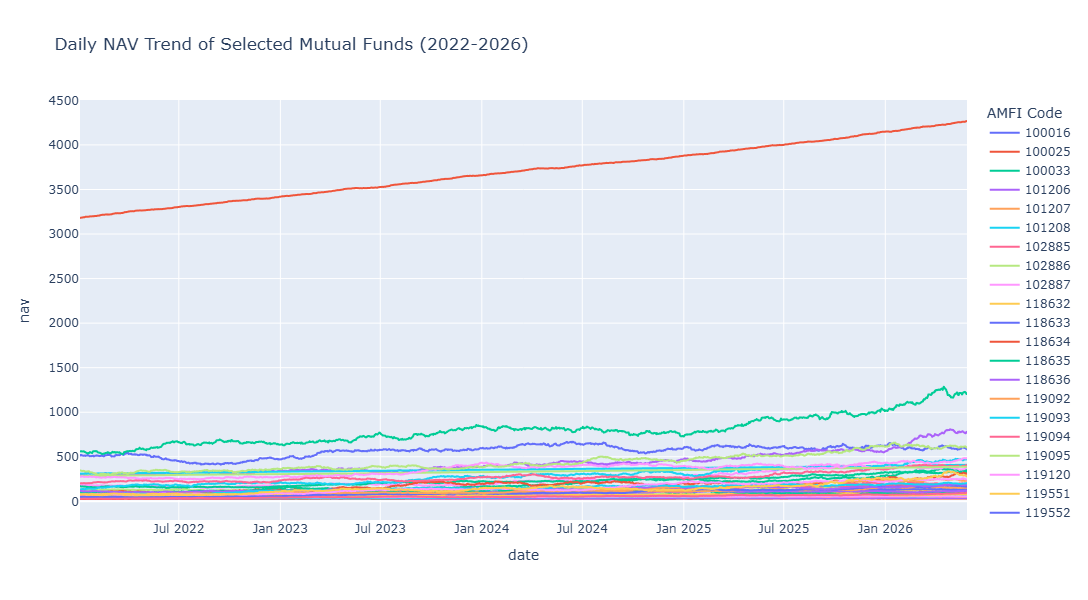

In [89]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Selected Mutual Funds (2022-2026)"
)

fig.update_layout(
    height=600,
    legend_title_text="AMFI Code"
)
fig.write_image(
    "reports/nav_trend.png"
)
fig.write_image(
    "reports/nav_trend.png"
)

fig.show()



In [51]:
import os

os.listdir("data/raw")


['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip_nav.csv',
 'hdfc_top100_nav.csv',
 'ICICI_Bluechip_nav.csv',
 'Kotak_Bluechip_nav.csv',
 'Nippon_LargeCap_nav.csv',
 'SBI_Bluechip_nav.csv']

In [52]:
aum = pd.read_csv(
    "data/raw/03_aum_by_fund_house.csv"
)

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [53]:
aum.columns


Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [54]:
aum.shape


(90, 5)

In [55]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


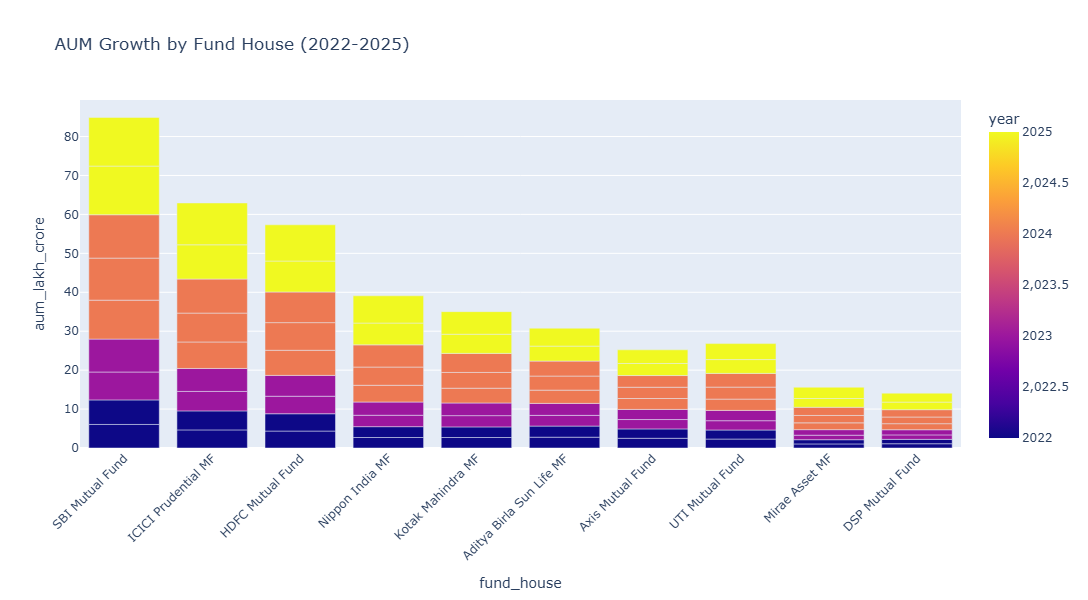

In [90]:
fig = px.bar(
    aum,
    x="fund_house",
    y="aum_lakh_crore",
    color="year",
    barmode="group",
    title="AUM Growth by Fund House (2022-2025)"
)

fig.update_layout(
    height=600,
    xaxis_tickangle=-45
)
fig.write_image("reports/aum_growth.png")
fig.show()

In [57]:
sip = pd.read_csv(
    "data/raw/04_monthly_sip_inflows.csv"
)

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [58]:
sip.columns


Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [59]:
sip.shape

(48, 6)

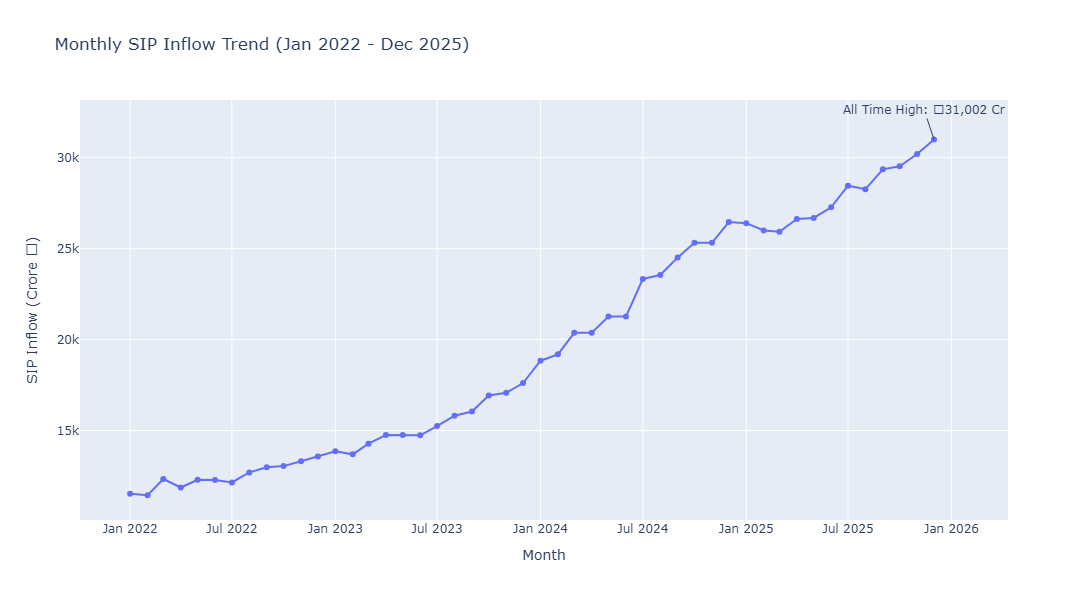

In [92]:
sip["month"] = sip["month"].astype(str)


fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)"
)

max_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_sip["month"],
    y=max_sip["sip_inflow_crore"],
    text="All Time High: ₹31,002 Cr",
    showarrow=True
)

fig.update_layout(
    height=600,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore ₹)"
)
fig.write_image("reports/sip_trend.png")

fig.show()

In [61]:
category = pd.read_csv(
    "data/raw/05_category_inflows.csv"
)

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [62]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [63]:
category.shape

(144, 3)

In [64]:
category_pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

category_pivot.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


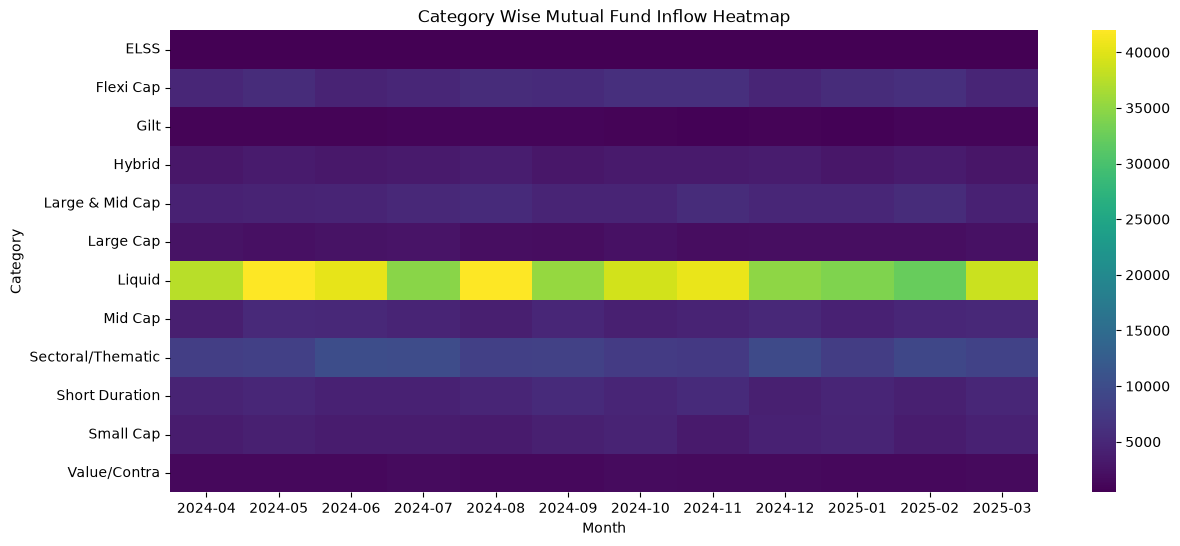

In [94]:
plt.figure(figsize=(14,6))

sns.heatmap(
    category_pivot,
    cmap="viridis",
    annot=False
)

plt.title("Category Wise Mutual Fund Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.savefig(
    "reports/category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [66]:
investor = pd.read_csv(
    "data/processed/clean_investor_transactions.csv"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [67]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

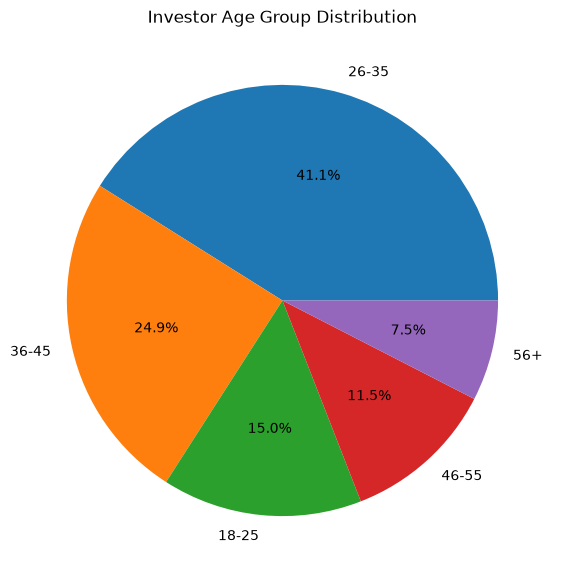

In [95]:
age_count = investor["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_count.values,
    labels=age_count.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.savefig("reports/age_distribution.png")

plt.show()

In [69]:
sip_age = investor[
    investor["transaction_type"]=="SIP"
]

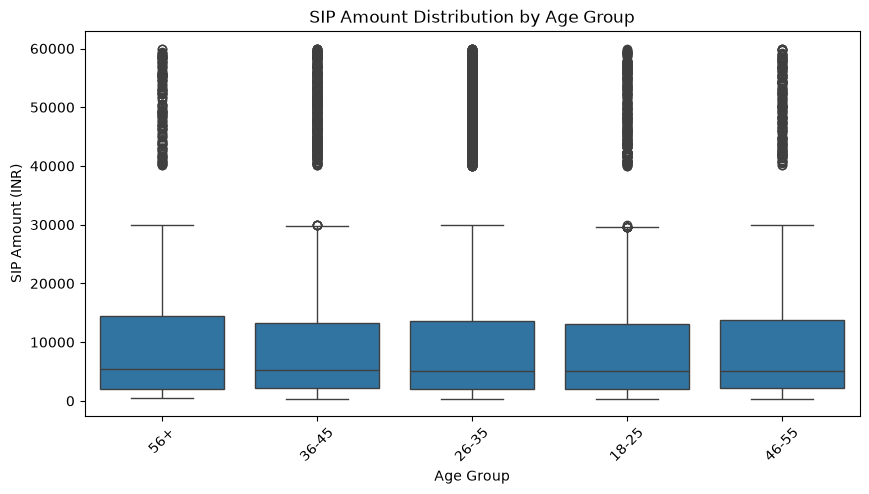

In [96]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=sip_age,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")

plt.xticks(rotation=45)
plt.savefig("reports/sip_boxplot.png")

plt.show()

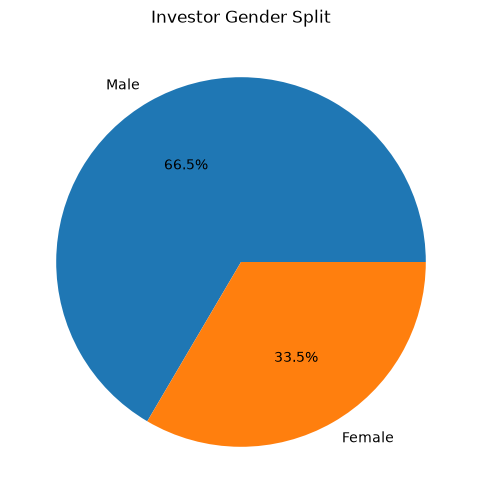

In [71]:
gender = investor["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Investor Gender Split")

plt.show()

In [72]:
state_sip = (
    investor[investor["transaction_type"]=="SIP"]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip.head()

state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Name: amount_inr, dtype: int64

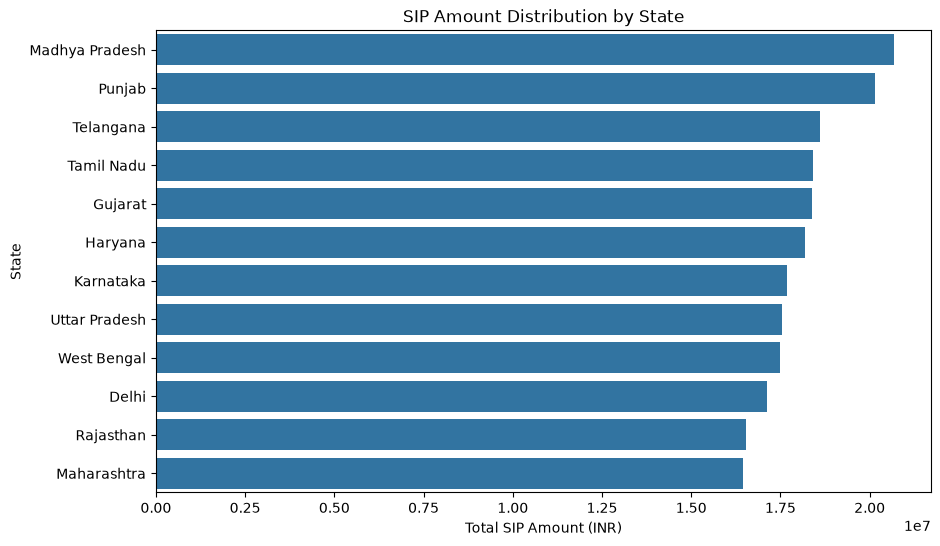

In [97]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("SIP Amount Distribution by State")

plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")
plt.savefig("reports/state_distribution.png")
plt.show()

In [74]:
investor["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

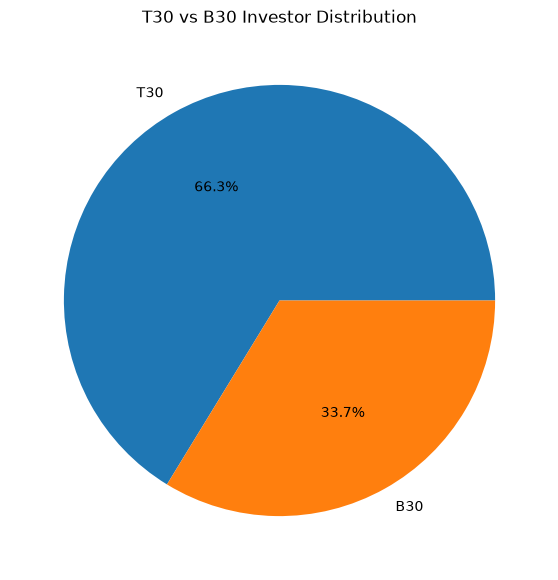

In [75]:
tier = investor["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier.values,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [76]:
folio = pd.read_csv(
    "data/raw/06_industry_folio_count.csv"
)

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [77]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [78]:
folio.shape

(21, 6)

In [79]:
folio["month"] = pd.to_datetime(folio["month"])

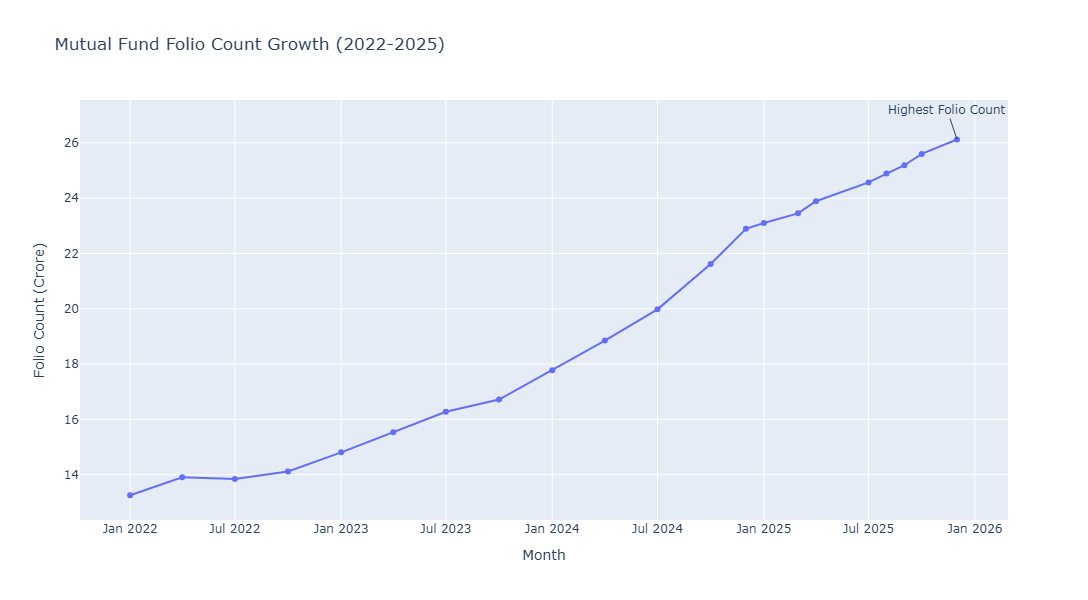

In [80]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Count Growth (2022-2025)"
)

fig.update_layout(
    height=600,
    xaxis_title="Month",
    yaxis_title="Folio Count (Crore)"
)
max_folio = folio.loc[
    folio["total_folios_crore"].idxmax()
]
max_folio
fig.add_annotation(
    x=max_folio["month"],
    y=max_folio["total_folios_crore"],
    text="Highest Folio Count",
    showarrow=True
)

fig.show()

In [81]:
selected_nav = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]

selected_nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [82]:
nav_matrix = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [83]:
daily_returns = nav_matrix.pct_change()

daily_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [84]:
corr_matrix = daily_returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


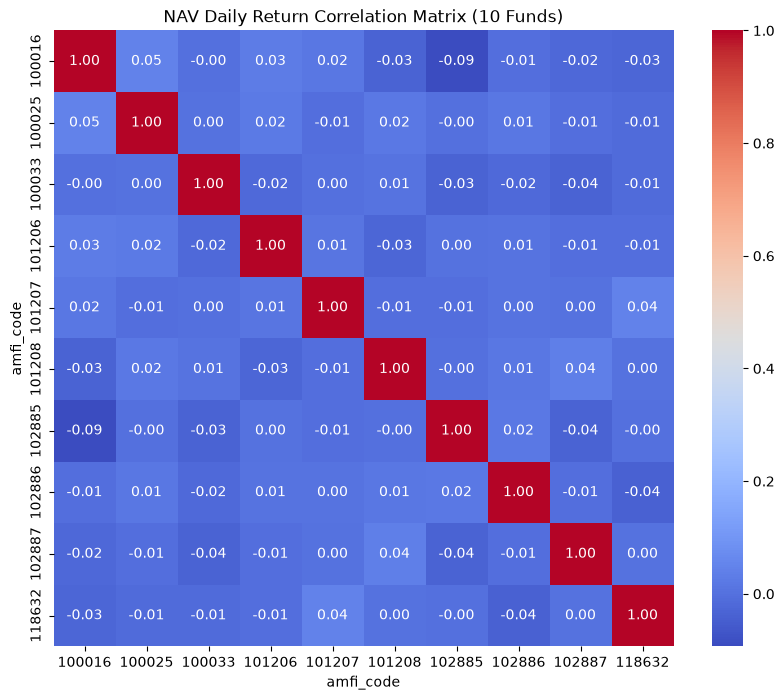

In [98]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "NAV Daily Return Correlation Matrix (10 Funds)"
)
plt.savefig("reports/correlation_heatmap.png")
plt.show()

In [86]:
holdings = pd.read_csv(
    "data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [87]:
sector_allocation = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

sector_allocation

,sector,weight_pct
0,Automobile,323.65
1,Banking,652.26
2,Cement,105.03
3,Consumer Goods,127.61
4,Diversified,169.23
5,Energy,117.91
6,FMCG,229.11
7,IT,455.47
8,Infrastructure,192.16
9,NBFC,119.09


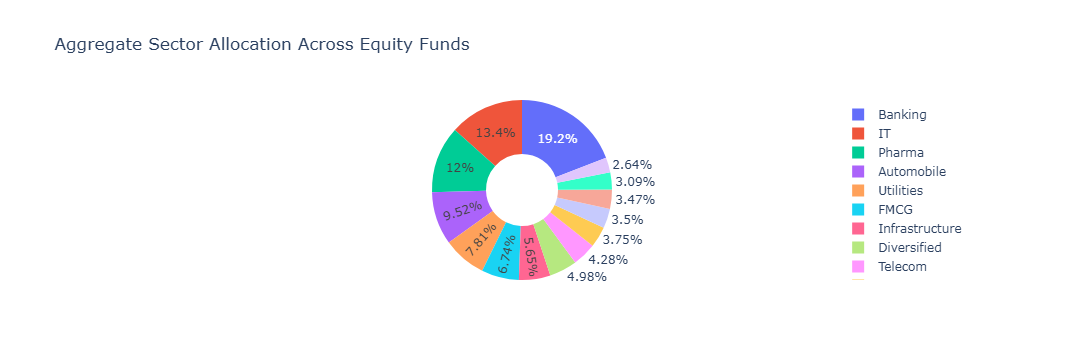

In [93]:
fig = px.pie(
    sector_allocation,
    values="weight_pct",
    names="sector",
    hole=0.4,
    title="Aggregate Sector Allocation Across Equity Funds"
)
fig.write_image(
    "reports/sector_allocation.png"
)

fig.show()

# EDA Key Findings

## 1. NAV Trend Analysis
NAV values of selected mutual fund schemes show overall growth trends between 2022 and 2026 with market-driven fluctuations.

(Reference: NAV Trend Analysis Chart)

## 2. AUM Growth Analysis
Large fund houses show significant growth in Assets Under Management from 2022 to 2025, indicating increasing investor participation.

(Reference: AUM Growth Chart)

## 3. SIP Inflow Trend
Monthly SIP inflows show a consistent upward trend with strong growth during the analysis period.

(Reference: SIP Inflow Time Series Chart)

## 4. Category Wise Inflows
Different mutual fund categories show varying inflow patterns, highlighting investor preference changes over time.

(Reference: Category Inflow Heatmap)

## 5. Investor Age Distribution
Investors are distributed across multiple age groups, showing participation from different demographics.

(Reference: Age Group Distribution Chart)

## 6. SIP Investment Behaviour
SIP investment amounts vary across age groups, showing differences in investment patterns.

(Reference: SIP Amount Box Plot)

## 7. Geographic Distribution
Certain states contribute a higher share of SIP investments compared to others.

(Reference: State-wise SIP Distribution Chart)

## 8. Folio Growth
Total mutual fund folio count increased significantly from 2022 to 2025, reflecting growth in retail participation.

(Reference: Folio Growth Chart)

## 9. Fund Return Correlation
Selected mutual fund schemes show correlation in daily NAV returns due to common market movements.

(Reference: NAV Return Correlation Heatmap)

## 10. Sector Allocation
Equity funds maintain diversification across multiple sectors through portfolio allocation.

(Reference: Sector Allocation Donut Chart)